In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel("/content/Telco_customer_churn.xlsx")

In [3]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [4]:
df.shape

(7043, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


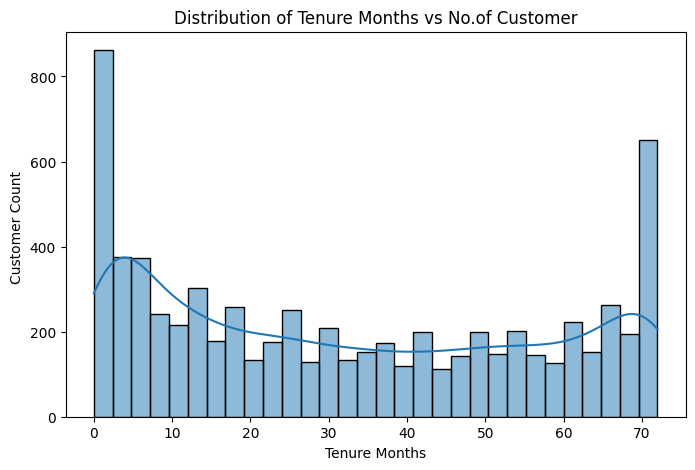

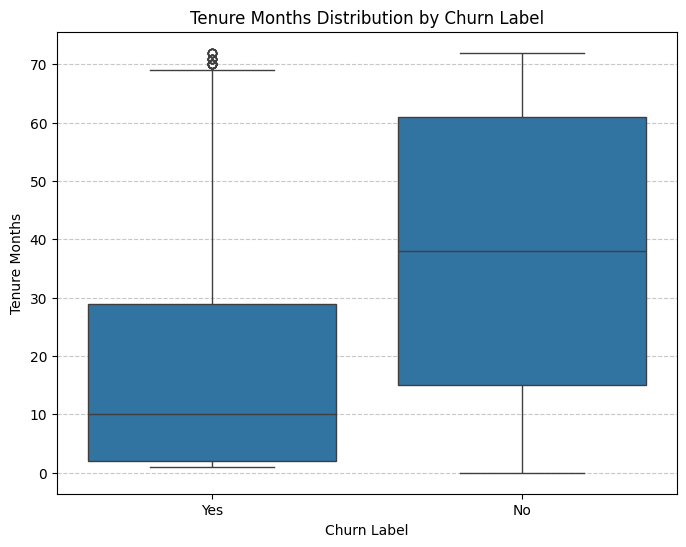

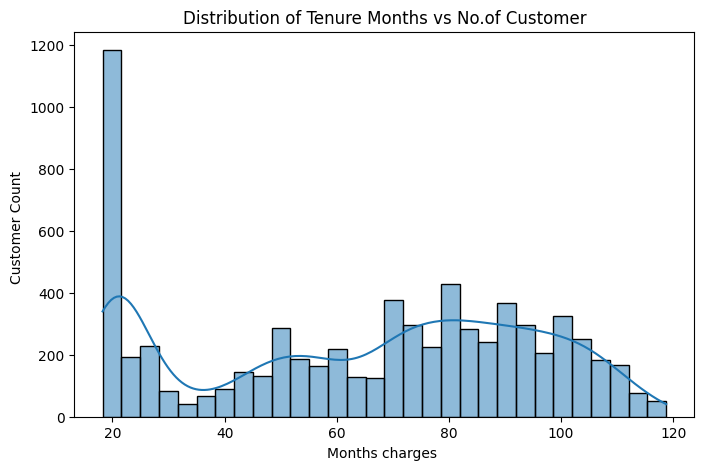

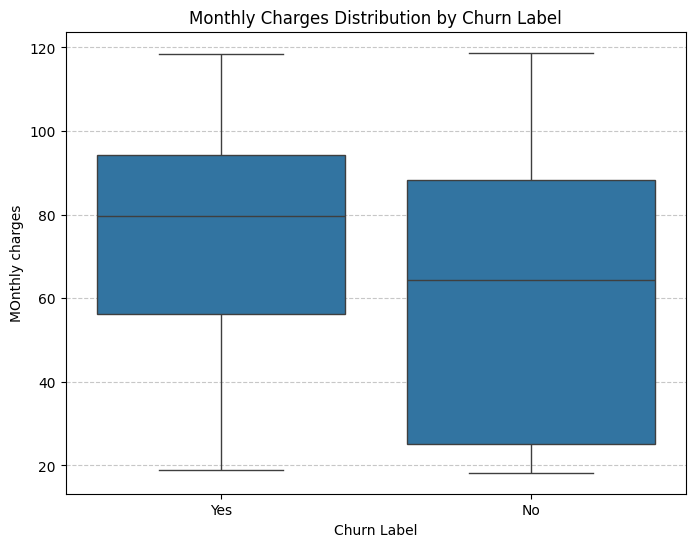

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'],bins=30,kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count ')
plt.title('Distribution of Tenure Months vs No.of Customer')
plt.show()
#

plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)
plt.title('Tenure Months Distribution by Churn Label')
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'],bins=30,kde=True)
plt.xlabel('Months charges ')
plt.ylabel('Customer Count ')
plt.title('Distribution of Tenure Months vs No.of Customer')
plt.show()
#

plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)
plt.title('Monthly Charges Distribution by Churn Label')
plt.xlabel('Churn Label')
plt.ylabel('MOnthly charges')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [9]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


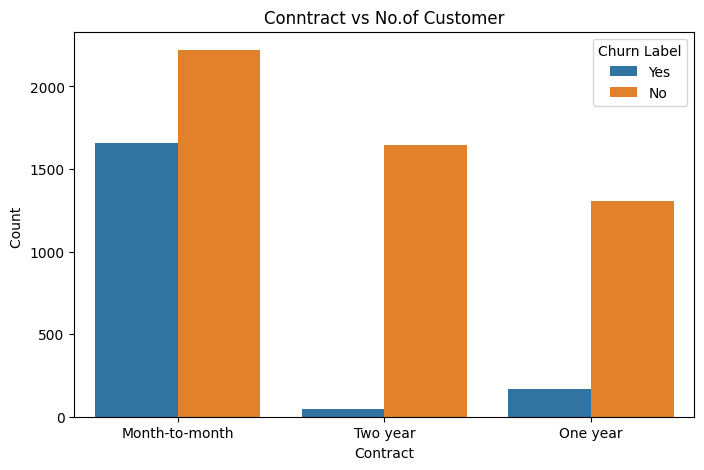

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract',hue='Churn Label',data=df)
plt.xlabel('Contract')
plt.ylabel('Count ')
plt.title('Conntract vs No.of Customer')
plt.show()

SIP date-10-06-2026

In [11]:
df['Total Charges'].isnull()

,Total Charges
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [12]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print("Rows with missing Total Charges before fix:", df['Total Charges'].isnull().sum())
df['Total Charges'] = df['Total Charges'].fillna(0)
print("Rows with missing Total Charges after fix:", df['Total Charges'].isnull().sum())

Rows with missing Total Charges before fix: 11
Rows with missing Total Charges after fix: 0


In [13]:
drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Longitude','Latitude','Churn Label','Churn Score','CLTV','Churn Reason','City']

In [14]:
df=df.drop(columns=drop_columns)

In [15]:
df.shape

(7043, 20)

In [16]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [17]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [18]:
df_encoded.shape

(7043, 31)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [20]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [21]:
df_encoded.shape

(7043, 31)

In [22]:
df_encoded

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,False,False,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,0,True,False,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,0,False,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,0,False,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False


In [23]:
X=df_encoded.drop(columns=['Churn Value'])
y=df_encoded['Churn Value']

Machine Learning Implementation

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
clf = RandomForestClassifier(
n_estimators=100, max_depth=3, random_state=42
)
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

In [27]:
y_pred = clf.predict(X_test)

In [28]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Accuracy: 0.77


In [29]:
cm=confusion_matrix(y_test,y_pred)

In [30]:
cm

array([[966,  43],
       [275, 125]])

In [31]:
from sklearn.metrics import classification_report

In [32]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.96      0.86      1009
           1       0.74      0.31      0.44       400

    accuracy                           0.77      1409
   macro avg       0.76      0.63      0.65      1409
weighted avg       0.77      0.77      0.74      1409



Approach 1 -Handle Imbalance Class

In [33]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

In [34]:
rf_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [35]:
y_pred_balanced= rf_balanced.predict(X_test)

In [36]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_balanced):.2f}")

Accuracy: 0.79


In [37]:
cm_balanced=confusion_matrix(y_test,y_pred_balanced)

In [38]:
print(classification_report(y_test,y_pred_balanced))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Approach 2 - HyperParameter tuning

In [39]:
rf_tuning = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

In [40]:
rf_tuning.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [41]:
y_pred_tuning= rf_tuning.predict(X_test)

In [42]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuning):.2f}")

Accuracy: 0.78


In [43]:
cm_tuning=confusion_matrix(y_test,y_pred_tuning)

In [44]:
print(classification_report(y_test,y_pred_tuning))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [45]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

In [46]:
rf_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [47]:
y_pred_balanced = rf_balanced.predict(X_test)

In [48]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)

In [49]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
print(accuracy_balanced)

0.7920511000709723


In [50]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
print(cm_balanced)

[[907 102]
 [191 209]]


In [51]:
print(classification_report(y_test,y_pred_balanced))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Approach 3 - Feature Engineering or Feature Importance Analysis

In [52]:
feature_importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_tuning.feature_importances_
})

In [53]:
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

In [54]:
print(feature_importances_df)

                                   Feature  Importance
0                            Tenure Months    0.179069
2                            Total Charges    0.136460
25                       Contract_Two year    0.102861
1                          Monthly Charges    0.093681
6                           Dependents_Yes    0.068517
10            Internet Service_Fiber optic    0.060228
28         Payment Method_Electronic check    0.046732
24                       Contract_One year    0.036682
13                     Online Security_Yes    0.029356
19                        Tech Support_Yes    0.021106
26                   Paperless Billing_Yes    0.018064
5                              Partner_Yes    0.015846
12     Online Security_No internet service    0.014973
18        Tech Support_No internet service    0.014799
22    Streaming Movies_No internet service    0.014360
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3         

In [55]:
print(feature_importances_df.tail(15))

                                   Feature  Importance
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3                              Gender_Male    0.012586
15                       Online Backup_Yes    0.012213
9                       Multiple Lines_Yes    0.011690
14       Online Backup_No internet service    0.010298
4                       Senior Citizen_Yes    0.010257
20        Streaming TV_No internet service    0.010186
23                    Streaming Movies_Yes    0.010161
27  Payment Method_Credit card (automatic)    0.009430
21                        Streaming TV_Yes    0.009289
17                   Device Protection_Yes    0.009101
29             Payment Method_Mailed check    0.008800
7                        Phone Service_Yes    0.003872
8          Multiple Lines_No phone service    0.003725


In [56]:
X_selected=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [57]:
X_train_sel,X_test_sel,y_train_sel,y_test_sel=train_test_split(X_selected,y,test_size=0.2,random_state=42)

In [58]:
rf_selected = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

In [59]:
rf_selected = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_selected.fit(X_train_sel, y_train_sel)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [60]:
y_pred_selected = rf_selected.predict(X_test_sel)

In [61]:
print(classification_report(y_test_sel, y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



new approach

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import pandas as pd

In [63]:
n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15, 20]

In [64]:
results = []

In [65]:
for n_trees in n_estimators_list:
    for depth in max_depth_list:

        rf = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42,
            class_weight='balanced'
        )

        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results.append({
            'Trees': n_trees,
            'Depth': depth,
            'Accuracy': accuracy,
            'Recall': recall,
            'precision': precision,
            'F1 Score': f1
        })

In [66]:
result_df = pd.DataFrame(results)

In [67]:
result_df = result_df.sort_values(
    by=['Recall', 'Accuracy'],
    ascending=False
)

In [68]:
print(result_df.head(20))

    Trees  Depth  Accuracy  Recall  precision  F1 Score
0     100      5  0.745919  0.8200   0.534202  0.646943
8     300      5  0.743790  0.8200   0.531605  0.645034
12    400      5  0.743790  0.8125   0.531915  0.642928
4     200      5  0.742370  0.8100   0.530278  0.640950
16    500      5  0.740951  0.8050   0.528736  0.638256
1     100     10  0.775727  0.7525   0.581081  0.655773
9     300     10  0.782825  0.7475   0.593254  0.661504
13    400     10  0.782825  0.7475   0.593254  0.661504
17    500     10  0.781405  0.7475   0.590909  0.660044
5     200     10  0.782115  0.7450   0.592445  0.660022
10    300     15  0.806246  0.6400   0.664935  0.652229
14    400     15  0.803407  0.6375   0.658915  0.648030
18    500     15  0.801987  0.6375   0.655527  0.646388
6     200     15  0.804826  0.6350   0.663185  0.648787
2     100     15  0.802697  0.6300   0.659686  0.644501
3     100     20  0.787793  0.5325   0.655385  0.587586
7     200     20  0.793471  0.5275   0.674121  0

final approach

In [69]:
from sklearn.model_selection import cross_val_score
rf_final=RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
scores=cross_val_score(rf_final,X,y,cv=5,scoring='accuracy')

In [70]:
scores

array([0.76721079, 0.79772889, 0.76224273, 0.78551136, 0.78409091])

In [71]:
scores.mean()

np.float64(0.7793569343183432)

In [72]:
cv_recall=cross_val_score(rf_final,X,y,cv=5,scoring='recall')

In [73]:
cv_recall.mean()

np.float64(0.7335350030823931)

ROC AUC

In [74]:
from sklearn.metrics import roc_auc_score,roc_curve
import matplotlib.pyplot as plt

In [75]:
y_prob=rf_tuning.predict_proba(X_test)[:,1]

In [76]:
from sklearn.metrics import roc_curve
fpr,tpr,thresholds=roc_curve(y_test,y_prob)

In [77]:
curoc=roc_auc_score(y_test,y_prob)

In [78]:
curoc

np.float64(0.857104806739346)

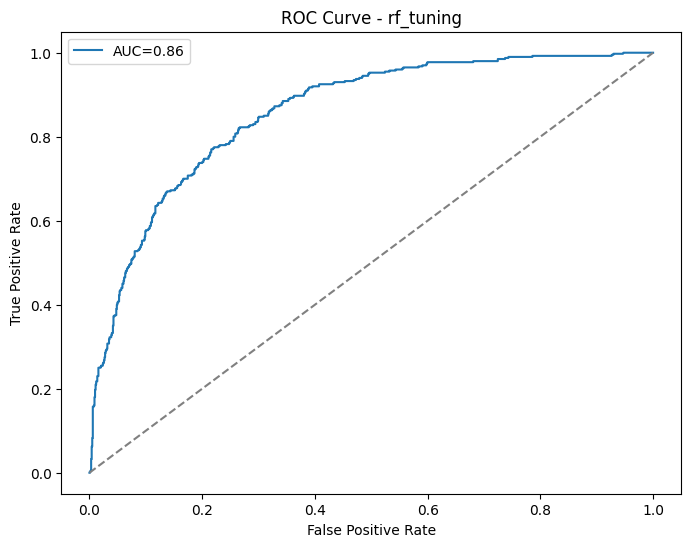

In [79]:
roc_curve_plot=plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f'AUC={curoc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - rf_tuning')
plt.legend()
plt.show()

Customer Segmentation

In [80]:
import pandas as pd

In [81]:
churn_probability = rf_tuning.predict_proba(X)[:, 1]

In [82]:
segmentation_data = pd.DataFrame({
    'Tenure Months': X['Tenure Months'],
    'Monthly Charges': X['Monthly Charges'],
    'Total Charges': X['Total Charges'],
    'Churn Probability': churn_probability
})

In [83]:
print(segmentation_data.head())

   Tenure Months  Monthly Charges  Total Charges  Churn Probability
0              2            53.85         108.15           0.676963
1              2            70.70         151.65           0.796013
2              8            99.65         820.50           0.805827
3             28           104.80        3046.05           0.563031
4             49           103.70        5036.30           0.517474


In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
scaler = StandardScaler()

In [86]:
scaled_data = scaler.fit_transform(segmentation_data)

In [87]:
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.02486837]
 [-1.23672422  0.19736523 -0.93887444  1.4138535 ]
 [-0.99240204  1.1595457  -0.64378925  1.44591771]
 [-0.17799476  1.33071079  0.3380854   0.65260685]
 [ 0.67713287  1.29415125  1.2161497   0.50375182]]


In [88]:
wcss = []

In [89]:
for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

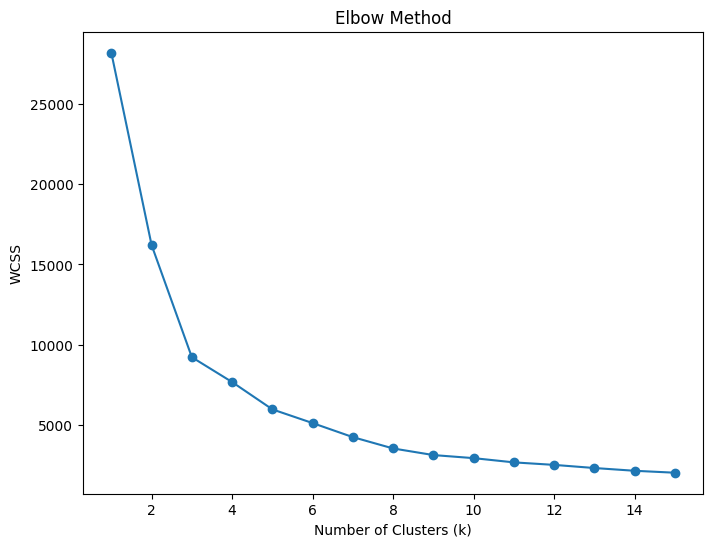

In [90]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 16), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [91]:
kmeans = KMeans(n_clusters=3, random_state=42)

In [92]:
clusters = kmeans.fit_predict(scaled_data)

In [93]:
segmentation_data['Cluster'] = clusters

In [94]:
cluster_summary = segmentation_data.groupby('Cluster').mean()

In [95]:
print(cluster_summary)

         Tenure Months  Monthly Charges  Total Charges  Churn Probability
Cluster                                                                  
0            32.051471        32.845761    1047.702141           0.120599
1            10.957752        71.961298     884.069671           0.691383
2            58.398884        90.430986    5278.001674           0.230647


In [96]:
cluster_names = {
    0: 'Budget Loyal Customers',
    1: 'High Risk New Customers',
    2: 'Loyal Premium Customers'
}

In [97]:
segmentation_data['Cluster Segment'] = (
    segmentation_data['Cluster'].map(cluster_names)
)

In [98]:
print("segmentation_data rows:", len(segmentation_data))
print("Cluster Segment value counts:\n", segmentation_data['Cluster Segment'].value_counts(dropna=False))
assert len(segmentation_data) > 0, "segmentation_data is empty - re-run all cells from 'Customer Segmentation' onward in order."

segmentation_data rows: 7043
Cluster Segment value counts:
 Cluster Segment
High Risk New Customers    2580
Budget Loyal Customers     2312
Loyal Premium Customers    2151
Name: count, dtype: int64


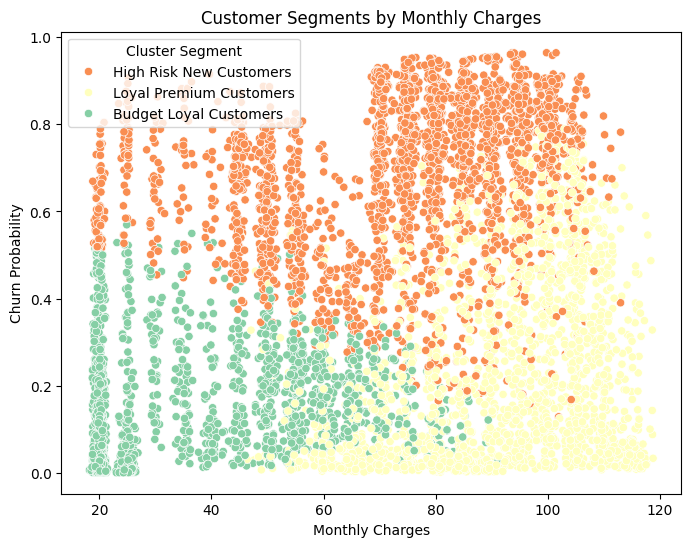

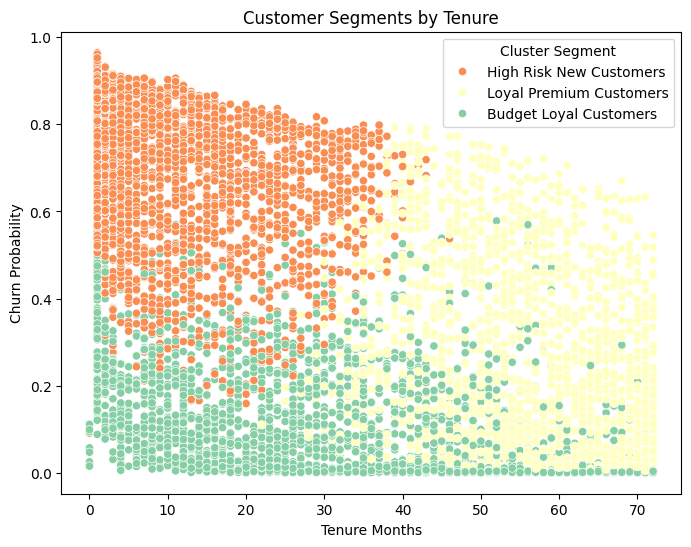

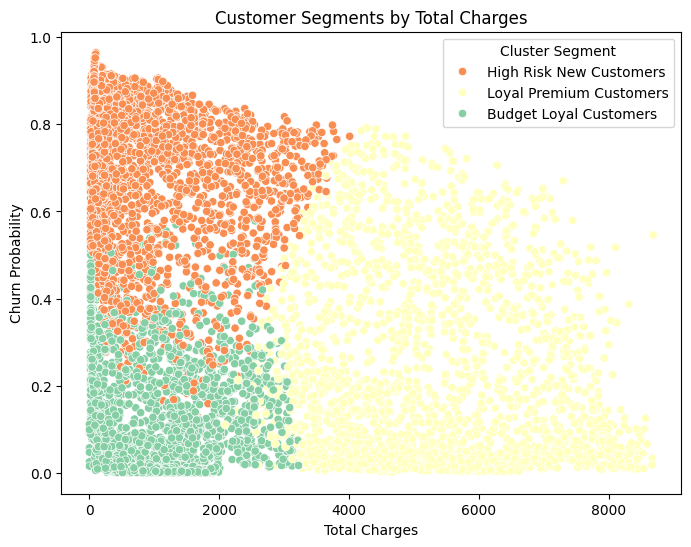

In [99]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Monthly Charges',
    y='Churn Probability',
    hue='Cluster Segment',
    data=segmentation_data,
    palette='Spectral'
)

plt.title('Customer Segments by Monthly Charges')
plt.show()

# Tenure Months vs Churn Probability

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Tenure Months',
    y='Churn Probability',
    hue='Cluster Segment',
    data=segmentation_data,
    palette='Spectral'
)

plt.title('Customer Segments by Tenure')
plt.show()

# Total Charges vs Churn Probability

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Total Charges',
    y='Churn Probability',
    hue='Cluster Segment',
    data=segmentation_data,
    palette='Spectral'
)

plt.title('Customer Segments by Total Charges')
plt.show()


Approach 4 - NEW MODEL: XGBoost (to improve on Random Forest)



In [100]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

In [101]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight (imbalance ratio): {scale_pos_weight:.2f}")

scale_pos_weight (imbalance ratio): 2.84


In [102]:
xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

In [103]:
xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [104]:
y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

In [105]:
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.2f}")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.76
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1009
           1       0.56      0.77      0.65       400

    accuracy                           0.76      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.80      0.76      0.77      1409



In [106]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

[[768 241]
 [ 91 309]]


In [107]:
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"XGBoost ROC AUC: {auc_xgb:.3f}")

XGBoost ROC AUC: 0.855


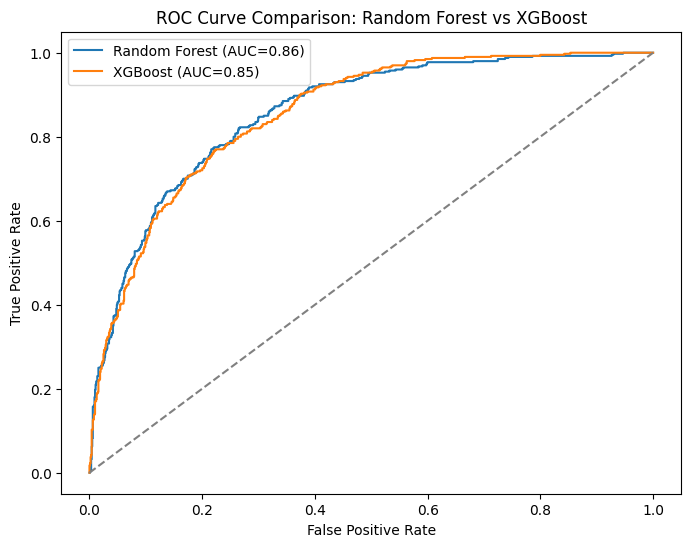

In [108]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC={curoc:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Random Forest vs XGBoost')
plt.legend()
plt.show()

In [109]:
xgb_feature_importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [110]:
print(xgb_feature_importances_df.head(15))

                                Feature  Importance
25                    Contract_Two year    0.271068
10         Internet Service_Fiber optic    0.094778
12  Online Security_No internet service    0.088801
11                  Internet Service_No    0.086784
24                    Contract_One year    0.084975
14    Online Backup_No internet service    0.064464
6                        Dependents_Yes    0.052003
23                 Streaming Movies_Yes    0.025094
0                         Tenure Months    0.022236
28      Payment Method_Electronic check    0.020919
21                     Streaming TV_Yes    0.015320
26                Paperless Billing_Yes    0.015170
13                  Online Security_Yes    0.015031
7                     Phone Service_Yes    0.012981
2                         Total Charges    0.012699


In [111]:
cv_accuracy_xgb = cross_val_score(xgb_clf, X, y, cv=5, scoring='accuracy')
cv_recall_xgb = cross_val_score(xgb_clf, X, y, cv=5, scoring='recall')

In [112]:
print(f"XGBoost CV Accuracy: {cv_accuracy_xgb.mean():.3f}")
print(f"XGBoost CV Recall:   {cv_recall_xgb.mean():.3f}")

XGBoost CV Accuracy: 0.762
XGBoost CV Recall:   0.758


Final Model Comparison: Random Forest (rf_tuning) vs XGBoost


In [113]:
comparison_df = pd.DataFrame({
    'Model': ['Random Forest (tuned)', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_tuning),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_tuning),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_tuning),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_tuning),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC AUC': [
        curoc,
        auc_xgb
    ]
})

In [114]:
print(comparison_df)

                   Model  Accuracy  Precision  Recall  F1 Score   ROC AUC
0  Random Forest (tuned)  0.782825   0.593254  0.7475  0.661504  0.857105
1                XGBoost  0.764372   0.561818  0.7725  0.650526  0.854913


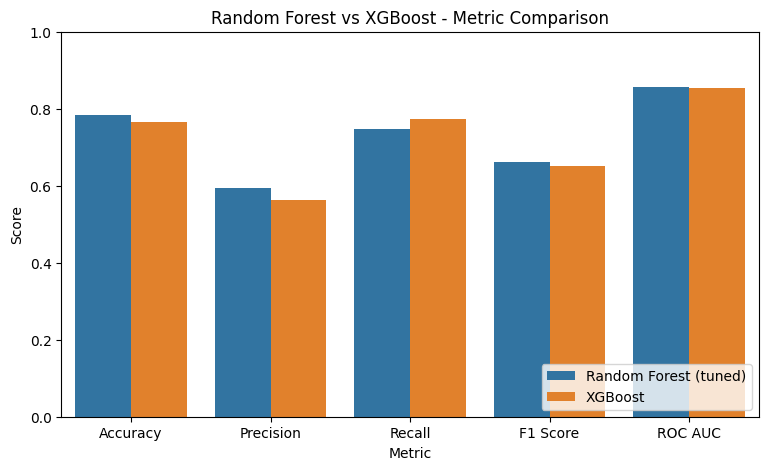

In [115]:
plt.figure(figsize=(9, 5))
comparison_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted)
plt.title('Random Forest vs XGBoost - Metric Comparison')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()